# Graph Coloring Problem

Here we show how to solve the graph coloring problem using OpenJij, [JijModeling](https://jij-inc-jijmodeling-tutorials-en.readthedocs-hosted.com/en/latest/introduction.html), and ommx-openjij-adapter. This problem is also mentioned in 6.1. Graph Coloring in [Lucas, 2014, "Ising formulations of many NP problems"](https://doi.org/10.3389/fphy.2014.00005).

## Overview of the Graph Coloring Problem

In a graph coloring problem, we color vertices on a given graph differently when they are on the same edge.
This problem is one of the famous NP-complete problems.

### Example

Consider an undirected graph with 6 vertices and some edges as shown below.

![](../../../assets/graph_coloring_01.png)

We can color this graph in three colors as follows:

![](../../../assets/graph_coloring_02.png)

No edge connects two vertices of the same color exist.

### Generalizing the Problem

Now let us generalize the problem and express it in a mathematical model. Consider an undirected graph $G = (V, E)$ with $N$ colors so that vertices connected by edges do not overlap.
We consider coloring an undirected graph $G=(V, E)$ with $N$ colors, and introduce variables $x_{v, n}$ which are 1 if vertex $v$ is colored with $n$ and 0 otherwise.

**Constraint: Vertices must be painted with one color**

It is not allowed to paint one vertex with two colors. This can be expressed as:

$$
\nonumber
\sum_{n=0}^{N-1} x_{v, n} = 1 \quad (\forall v \in V) \tag{1}
$$

**Objective Function: Minimize edges whose vertices at both ends have the same color**

The problem setup for the graph coloring problem requires that the vertices at both ends of every edge be painted with a different color. This can be expressed as:

$$
\nonumber
\min \quad \sum_{n=0}^{N-1} \sum_{(uv) \in E} x_{u, n} x_{v, n} \tag{2}
$$

where E is a set of edges on graph $G$.
This objective function is quite complicated.
Let us see the table below.

| $x_{u,n}$ | $x_{v,n}$ | $x_{u,n}x_{v,n}$ |  
|-----------|-----------|------------------|
|     0     |     0     |         0        |
|     0     |     0     |         0        |
|     1     |     0     |         0        |
|     1     |     1     |         1        |

As we defined above if vertex$u$ is colored by $n$, $x_{u,n}=1$, so only when both $x_{u,n}$ and $x_{v,n}$ are 1, $x_{u,n}x_{v,n} = 1$ in the above table, and 0 otherwise.
When two vertices on every edge have different colors, the value of this objective function becomes 0.
Thus, this objective function is an indicator of how much graph coloring has been achieved.

## Formulation with JijModeling

Next, we show how to formulate the above mathematical model using JijModeling. We first define the variables and parameters used in the model.

In [1]:
import jijmodeling as jm

problem = jm.Problem("Graph Coloring")

V = problem.Natural('V')
E = problem.Graph('E')
N = problem.Natural('N')
x = problem.BinaryVar('x', shape=(V, N))

Here, `V` is the number of vertices, `E` is the edge set of graph $G$, and `N` is the number of colors. `x` is a two-dimensional binary variable corresponding to $x_{v,n}$.

### Constraint

Let us formulate the constraint in equation (1) as follows.

In [2]:
problem += problem.Constraint("one-color", lambda v: jm.sum(N, lambda n: x[v, n]) == 1, domain=V)

### Objective Function

Let us formulate the objective function in equation (2) as follows.

In [3]:
problem += jm.sum(jm.product(N, E), lambda n, e: x[e[0], n] * x[e[1], n])

Let us display the formulated mathematical model in the Jupyter Notebook.

In [4]:
problem

Problem(name="Graph Coloring", sense=MINIMIZE, objective=sum(set((N, E)).map(lambda ((n, e): Tuple[natural, Tuple[natural, natural]]): x[e[0], n] * x[e[1], n])), constraints={one-color: [Constraint(name="one-color", , lambda v: sum(N.map(lambda (n: natural): x[v, n])) == 1, domain=set(V)),],})

## Creating an Instance

Let us set up the graph for graph coloring.

In [5]:
import networkx as nx

# set the number of vertices
inst_V = 12
# set the number of colors
inst_N = 4
# create a random graph
inst_G = nx.gnp_random_graph(inst_V, 0.4)
# get information of edges
inst_E = [list(edge) for edge in inst_G.edges]
instance_data = {'V': inst_V, 'N': inst_N, 'E': inst_E}

Let us color the following graph.

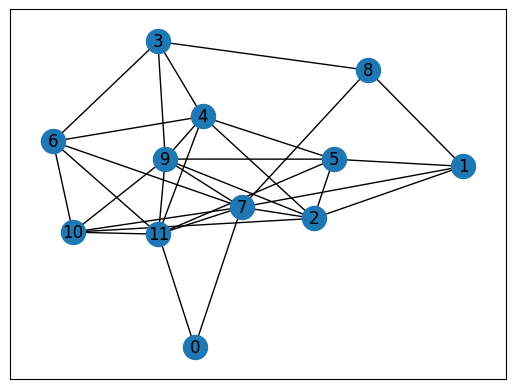

In [6]:
import matplotlib.pyplot as plt

pos = nx.spring_layout(inst_G)
nx.draw_networkx(inst_G, pos=pos, with_labels=True)
plt.show()

## Running Optimization with OpenJij

Let us solve the optimization problem using OpenJij's simulated annealing.

In [7]:
from ommx_openjij_adapter import OMMXOpenJijSAAdapter

instance = problem.eval(instance_data)

adapter = OMMXOpenJijSAAdapter(instance)
best_sample = adapter.sample(instance, num_reads=100).best_feasible_unrelaxed

## Visualizing the Solution

Using the obtained solution, let us color the graph. The following code displays the colored graph.

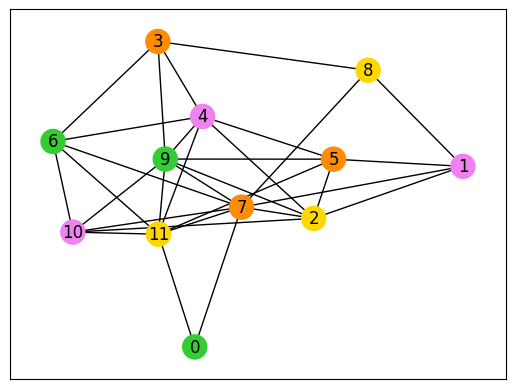

In [8]:
df = best_sample.decision_variables_df
indices = df[(df["name"] == "x") & (df["value"] > 0.5)]["subscripts"].to_list()
node_colors = [-1] * len(indices)
colorlist = ["gold", "violet", "limegreen", "darkorange"]
for i, j in indices:
    node_colors[i] = colorlist[j]
nx.draw_networkx(inst_G, pos=pos, node_color=node_colors, with_labels=True)
plt.show()